# Load Data

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "Luilma"
os.environ['KAGGLE_KEY'] = "KGAT_cfadef3ba9e901d0d8d1cfe8ee326e1e"

!kaggle datasets download -d blastchar/telco-customer-churn
!unzip -q -o telco-customer-churn.zip

print("data berhasil diunduh dan diekstraks!")

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
telco-customer-churn.zip: Skipping, found more recently modified local copy (use --force to force download)
data berhasil diunduh dan diekstraks!


In [ ]:
!pip install optuna
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, accuracy_score)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

display(df.head())
print(f"\n[1] Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



[1] Data loaded: 7043 rows, 21 columns


In [ ]:
print('Total missing values:')
print(df.isnull().sum())

Total missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Preprocessing

In [ ]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

#menghilangkan spasi, convert ke numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True);

#target encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"   - Missing values handled")
print(f"   - Churn distribution: {df['Churn'].value_counts().to_dict()}")
print(f"   - Class ratio: {df['Churn'].value_counts(normalize=True).round(3).to_dict()}")

   - Missing values handled
   - Churn distribution: {0: 5174, 1: 1869}
   - Class ratio: {0: 0.735, 1: 0.265}


# Feature Engineering

In [ ]:
#Biaya per bulan relatif terhadap lama berlangganan
df['ChargePerTenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# Total layanan yang dipakai
service_cols = ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

def count_services(row):
    count = 0
    for col in service_cols:
        if row[col] not in ['No', 'No phone service', 'No internet service']:
            count += 1
    return count

df['TotalServices'] = df.apply(count_services, axis=1)

#Apakah pakai streaming
df['HasStreaming'] = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).astype(int)

#Apakah pakai security/backup
df['HasProtection'] = ((df['OnlineSecurity'] == 'Yes') | (df['OnlineBackup'] == 'Yes') |
                       (df['DeviceProtection'] == 'Yes')).astype(int)

print(f"   - Added features: ChargePerTenure, TotalServices, HasStreaming, HasProtection")

   - Added features: ChargePerTenure, TotalServices, HasStreaming, HasProtection


# Encoding Categorical Features

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f"   - Encoded {len(cat_cols)} categorical columns: {cat_cols}")

# Fill any remaining NaN after feature engineering
df.fillna(df.median(numeric_only=True), inplace=True)

   - Encoded 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# SMOTE

In [ ]:
#split data sebelum SMOTE
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   - Train: {X_train.shape[0]} samples")
print(f"   - Test:  {X_test.shape[0]} samples")
print(f"   - Train churn distribution: {y_train.value_counts().to_dict()}")

   - Train: 5634 samples
   - Test:  1409 samples
   - Train churn distribution: {0: 4139, 1: 1495}


In [ ]:
#melakukan SMOTE (pada train data)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"   - Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"   - After SMOTE:  {pd.Series(y_train_sm).value_counts().to_dict()}")

   - Before SMOTE: {0: 4139, 1: 1495}
   - After SMOTE:  {0: 4139, 1: 4139}


# Optuna Hyperparameter Tuning

In [ ]:
#optuna hyperparameter tuning
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 3.0),
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 42,
        'tree_method': 'hist'
    }

    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_sm, y_train_sm,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=False)

best_params = study.best_params
print(f"   - Best AUC-ROC (CV): {study.best_value:.4f}")
print(f"   - Best params: {best_params}")

   - Best AUC-ROC (CV): 0.9321
   - Best params: {'n_estimators': 487, 'max_depth': 7, 'learning_rate': 0.035546956304666796, 'subsample': 0.774635184176767, 'colsample_bytree': 0.733880237725574, 'min_child_weight': 2, 'gamma': 0.8069240572901403, 'reg_alpha': 0.1844793110220866, 'reg_lambda': 0.44796544219196055, 'scale_pos_weight': 1.7925076700883464}


# Train Final Model

In [ ]:
best_params.update({
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42,
    'tree_method': 'hist'
})

model = XGBClassifier(**best_params)
model.fit(X_train_sm, y_train_sm,
          eval_set=[(X_test, y_test)],
          verbose=False)

print("   - Model trained successfully!")

   - Model trained successfully!


# Evaluasi

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)

print(f"\n   {'Metric':<20} {'Score':>10}")
print(f"   {'-'*32}")
print(f"   {'Accuracy':<20} {acc:>10.4f}")
print(f"   {'Precision':<20} {prec:>10.4f}")
print(f"   {'Recall':<20} {rec:>10.4f}")
print(f"   {'F1-Score':<20} {f1:>10.4f}")
print(f"   {'AUC-ROC':<20} {auc:>10.4f}")

print("\n   Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


   Metric                    Score
   --------------------------------
   Accuracy                 0.7622
   Precision                0.5409
   Recall                   0.6898
   F1-Score                 0.6063
   AUC-ROC                  0.8216

   Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.54      0.69      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



# Visualisasi

   - Calculating SHAP values (this may take a moment)...


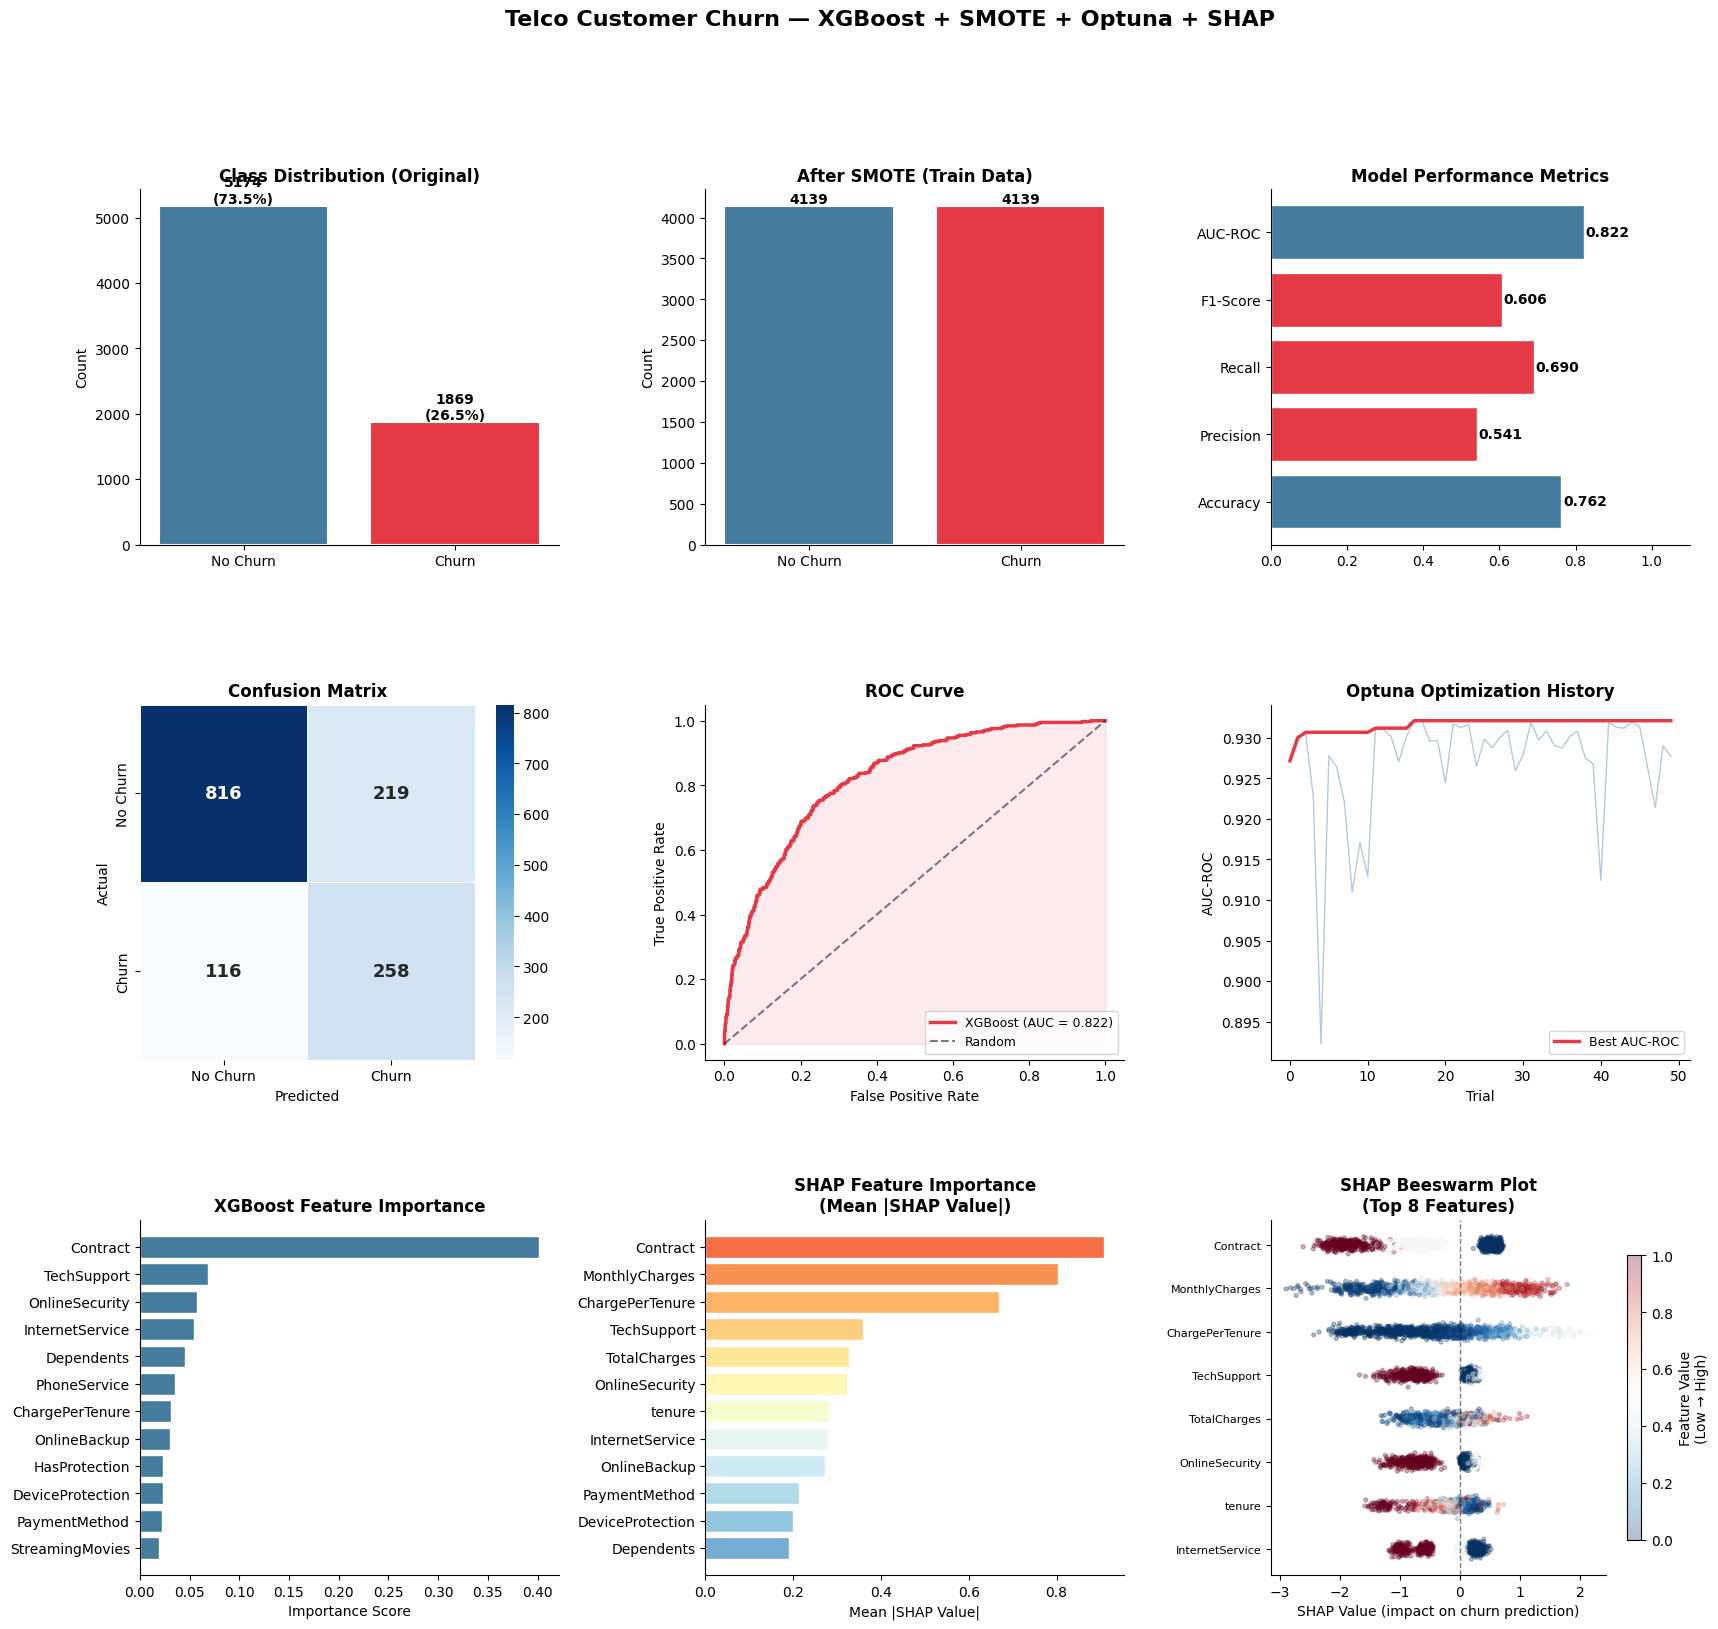

In [ ]:
fig = plt.figure(figsize=(20, 18))
fig.suptitle('Telco Customer Churn — XGBoost + SMOTE + Optuna + SHAP',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = {'main': '#E63946', 'sec': '#457B9D', 'bg': '#F1FAEE', 'dark': '#1D3557'}

# --- Plot 1: Class Distribution ---
ax1 = fig.add_subplot(gs[0, 0])
churn_counts = y.value_counts()
bars = ax1.bar(['No Churn', 'Churn'],
               [churn_counts[0], churn_counts[1]],
               color=[colors['sec'], colors['main']], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [churn_counts[0], churn_counts[1]]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{val}\n({val/len(y)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax1.set_title('Class Distribution (Original)', fontweight='bold')
ax1.set_ylabel('Count')
ax1.spines[['top', 'right']].set_visible(False)

# --- Plot 2: After SMOTE ---
ax2 = fig.add_subplot(gs[0, 1])
sm_counts = pd.Series(y_train_sm).value_counts()
bars2 = ax2.bar(['No Churn', 'Churn'],
                [sm_counts[0], sm_counts[1]],
                color=[colors['sec'], colors['main']], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, [sm_counts[0], sm_counts[1]]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val}', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('After SMOTE (Train Data)', fontweight='bold')
ax2.set_ylabel('Count')
ax2.spines[['top', 'right']].set_visible(False)

# --- Plot 3: Metrics Summary ---
ax3 = fig.add_subplot(gs[0, 2])
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1, 'AUC-ROC': auc}
metric_colors = [colors['sec'] if v >= 0.75 else colors['main'] for v in metrics.values()]
bars3 = ax3.barh(list(metrics.keys()), list(metrics.values()),
                 color=metric_colors, edgecolor='white')
for bar, val in zip(bars3, metrics.values()):
    ax3.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
ax3.set_xlim(0, 1.1)
ax3.set_title('Model Performance Metrics', fontweight='bold')
ax3.spines[['top', 'right']].set_visible(False)

# --- Plot 4: Confusion Matrix ---
ax4 = fig.add_subplot(gs[1, 0])
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'})
ax4.set_title('Confusion Matrix', fontweight='bold')
ax4.set_ylabel('Actual')
ax4.set_xlabel('Predicted')

# --- Plot 5: ROC Curve ---
ax5 = fig.add_subplot(gs[1, 1])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax5.plot(fpr, tpr, color=colors['main'], lw=2.5,
         label=f'XGBoost (AUC = {auc:.3f})')
ax5.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random')
ax5.fill_between(fpr, tpr, alpha=0.1, color=colors['main'])
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.set_title('ROC Curve', fontweight='bold')
ax5.legend(loc='lower right', fontsize=9)
ax5.spines[['top', 'right']].set_visible(False)

# --- Plot 6: Optuna Optimization History ---
ax6 = fig.add_subplot(gs[1, 2])
trial_values = [t.value for t in study.trials]
ax6.plot(trial_values, color=colors['sec'], alpha=0.4, linewidth=1)
running_max = pd.Series(trial_values).cummax()
ax6.plot(running_max, color=colors['main'], linewidth=2.5, label='Best AUC-ROC')
ax6.set_xlabel('Trial')
ax6.set_ylabel('AUC-ROC')
ax6.set_title('Optuna Optimization History', fontweight='bold')
ax6.legend(fontsize=9)
ax6.spines[['top', 'right']].set_visible(False)

# --- Plot 7: XGBoost Feature Importance ---
ax7 = fig.add_subplot(gs[2, 0])
feat_importance = pd.Series(model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=True).tail(12)
bars7 = ax7.barh(feat_importance.index, feat_importance.values,
                 color=colors['sec'], edgecolor='white')
ax7.set_title('XGBoost Feature Importance', fontweight='bold')
ax7.set_xlabel('Importance Score')
ax7.spines[['top', 'right']].set_visible(False)

# --- Plot 8 & 9: SHAP ---
print("   - Calculating SHAP values (this may take a moment)...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

ax8 = fig.add_subplot(gs[2, 1])
shap_mean = np.abs(shap_values).mean(axis=0)
shap_df = pd.Series(shap_mean, index=X.columns).sort_values(ascending=True).tail(12)
colors_shap = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(shap_df)))
bars8 = ax8.barh(shap_df.index, shap_df.values, color=colors_shap, edgecolor='white')
ax8.set_title('SHAP Feature Importance\n(Mean |SHAP Value|)', fontweight='bold')
ax8.set_xlabel('Mean |SHAP Value|')
ax8.spines[['top', 'right']].set_visible(False)

# --- Plot 9: SHAP Beeswarm / Summary ---
ax9 = fig.add_subplot(gs[2, 2])
top_features_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-8:]
top_shap = shap_values[:, top_features_idx]
top_feat_names = X.columns[top_features_idx]
top_feat_vals = X_test.iloc[:, top_features_idx].values

for i, (name, sv, fv) in enumerate(zip(top_feat_names, top_shap.T, top_feat_vals.T)):
    fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    jitter = np.random.normal(i, 0.07, len(sv))
    scatter = ax9.scatter(sv, jitter, c=fv_norm, cmap='RdBu_r',
                          alpha=0.3, s=8, vmin=0, vmax=1)

ax9.set_yticks(range(len(top_feat_names)))
ax9.set_yticklabels(top_feat_names, fontsize=8)
ax9.axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
ax9.set_xlabel('SHAP Value (impact on churn prediction)')
ax9.set_title('SHAP Beeswarm Plot\n(Top 8 Features)', fontweight='bold')
ax9.spines[['top', 'right']].set_visible(False)
plt.colorbar(scatter, ax=ax9, label='Feature Value\n(Low → High)', shrink=0.8)

In [ ]:
print(f"  Model        : XGBoost (Optuna-tuned)")
print(f"  Imbalance    : Handled with SMOTE")
print(f"  Explainability: SHAP Analysis")
print(f"  Accuracy     : {acc:.4f} ({acc*100:.2f}%)")
print(f"  Precision    : {prec:.4f}")
print(f"  Recall       : {rec:.4f}")
print(f"  F1-Score     : {f1:.4f}")
print(f"  AUC-ROC      : {auc:.4f}")
print("=" * 60)

top5 = pd.Series(np.abs(shap_values).mean(axis=0),
                 index=X.columns).sort_values(ascending=False).head(5)
print("\nTop 5 Faktor Penyebab Churn (SHAP):")
for i, (feat, val) in enumerate(top5.items(), 1):
    print(f"  {i}. {feat:<25} (SHAP: {val:.4f})")

  Model        : XGBoost (Optuna-tuned)
  Imbalance    : Handled with SMOTE
  Explainability: SHAP Analysis
  Accuracy     : 0.7622 (76.22%)
  Precision    : 0.5409
  Recall       : 0.6898
  F1-Score     : 0.6063
  AUC-ROC      : 0.8216

Top 5 Faktor Penyebab Churn (SHAP):
  1. Contract                  (SHAP: 0.9088)
  2. MonthlyCharges            (SHAP: 0.8040)
  3. ChargePerTenure           (SHAP: 0.6682)
  4. TechSupport               (SHAP: 0.3588)
  5. TotalCharges              (SHAP: 0.3276)
